In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = pd.read_csv("Telco-Customer-Churn.csv")

data = data.drop("customerID", axis=1)

data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

X = data.drop("Churn", axis=1)
y = data["Churn"]

X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")
X["TotalCharges"] = X["TotalCharges"].fillna(X["TotalCharges"].median())

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8183108587650816


In [2]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[927 109]
 [147 226]]
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      1036
           1       0.67      0.61      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [3]:
model.predict(X_test.iloc[[0]])

array([1], dtype=int64)

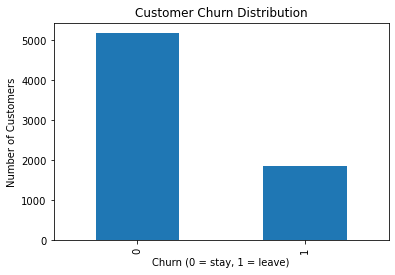

In [4]:
import matplotlib.pyplot as plt

data["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = stay, 1 = leave)")
plt.ylabel("Number of Customers")
plt.show()

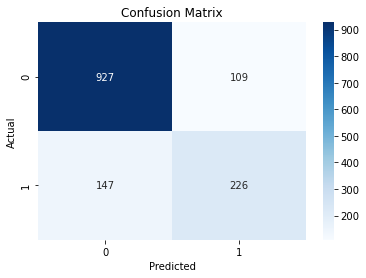

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

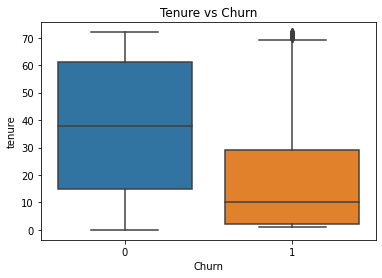

In [7]:
import seaborn as sns

sns.boxplot(x=data["Churn"], y=data["tenure"])
plt.title("Tenure vs Churn")
plt.show()